# HighRes-Net Inference on Synthetic Microscopy Data

This notebook demonstrates inference on synthetic microscopy datasets with 7 low-resolution views.

## 1. Setup and Imports

In [51]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Add src directory to path
sys.path.insert(0, '../src')

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from DataLoader import SimpleMicroscopyDataset, collateFunction
from DeepNetworks.HRNet import HRNet
from utils import imsetshow

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch Version: 2.7.1+cu118
CUDA Available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Memory: 8.59 GB


## 2. Load Configuration

In [52]:
# Load configuration
config_path = '../config/config.json'
with open(config_path, 'r') as f:
    config = json.load(f)

print("Configuration:")
print(f"  n_views: {config['training']['n_views']}")
print(f"  min_L: {config['training']['min_L']}")
print(f"  batch_size: {config['training']['batch_size']}")
print(f"  patch_size: {config['training']['patch_size']}")

Configuration:
  n_views: 8
  min_L: 8
  batch_size: 2
  patch_size: 32


## 3. Specify Your Dataset Directory

In [53]:
# MODIFY THIS PATH to point to your microscopy dataset folder
# Expected structure:
#   your_dataset/
#     scene_1/
#       LR_1.png
#       LR_2.png
#       ... (up to 7 LR images)
#       HR.png (optional, for scoring)
#     scene_2/
#       ...

dataset_root = "D:\GUC\Datasets\HighRes input test"  # <-- CHANGE THIS

# List all scene folders
scene_dirs = [d for d in Path(dataset_root).iterdir() if d.is_dir()]
scene_dirs = sorted(scene_dirs)

print(f"Found {len(scene_dirs)} scenes")
if len(scene_dirs) > 0:
    print(f"First 5 scenes: {[d.name for d in scene_dirs[:5]]}")

Found 1 scenes
First 5 scenes: ['scene_1']


<>:12: SyntaxWarning: invalid escape sequence '\G'
<>:12: SyntaxWarning: invalid escape sequence '\G'
C:\Users\Youssef\AppData\Local\Temp\ipykernel_18388\44667966.py:12: SyntaxWarning: invalid escape sequence '\G'
  dataset_root = "D:\GUC\Datasets\HighRes input test"  # <-- CHANGE THIS


## 4. Load Model Architecture

In [54]:
# Initialize HRNet model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = HRNet(config['network'])
model.to(device)
model.eval()

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model total parameters: {total_params:,}")

Using device: cuda
Model total parameters: 591,818


## 5. Load Pre-trained Weights (Optional)

In [55]:
# If you have pre-trained weights, load them here
# weights_path = "../models/weights/HRNet.pth"  # <-- Modify path to your weights

# if os.path.exists(weights_path):
#     print(f"Loading weights from {weights_path}")
#     state_dict = torch.load(weights_path, map_location=device)
#     model.load_state_dict(state_dict)
#     print("Weights loaded successfully!")
# else:
#     print(f"Warning: {weights_path} not found. Using random initialization.")

print("Skipping weight loading - model uses random initialization for this test.")
print("To use trained weights, uncomment the code above and specify the path.")

Skipping weight loading - model uses random initialization for this test.
To use trained weights, uncomment the code above and specify the path.


## 6. Create Dataset and DataLoader

In [56]:
# Convert Path objects to strings
scene_dirs_str = [str(d) for d in scene_dirs]

# Create dataset
dataset = SimpleMicroscopyDataset(
    imset_dirs=scene_dirs_str,
    config=config['training'],
    max_views=config['training']['n_views']
)

print(f"Dataset size: {len(dataset)} scenes")

# Create dataloader
min_L = config['training']['min_L']
batch_size = config['training']['batch_size']

dataloader = DataLoader(
    dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,  # Set to 0 for debugging; increase if needed
    collate_fn=collateFunction(min_L=min_L),
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"DataLoader created with batch_size={batch_size} (min_L={min_L})")

Dataset size: 1 scenes
DataLoader created with batch_size=2 (min_L=8)


## 7. Run Inference on One Batch

In [57]:
# Get first batch
batch = next(iter(dataloader))
lrs, alphas, hrs, hr_maps, names = batch

print(f"Batch loaded:")
print(f"  LR shape: {lrs.shape}")
print(f"  Alphas shape: {alphas.shape}")
print(f"  HR shape: {hrs.shape}")
print(f"  HR_map shape: {hr_maps.shape}")
print(f"  Scene names: {names}")

# Move to device
lrs = lrs.float().to(device)
alphas = alphas.float().to(device)

print(f"\nData moved to {device}")

  HR resampled from (384, 384) to (384, 384) to match 3x SR output
Batch loaded:
  LR shape: torch.Size([1, 8, 128, 128])
  Alphas shape: torch.Size([1, 8])
  HR shape: torch.Size([1, 384, 384])
  HR_map shape: torch.Size([1, 384, 384])
  Scene names: ['scene_1']

Data moved to cuda


## 8. Forward Pass and GPU Memory Check

In [58]:
# Monitor GPU memory before inference
if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()
    mem_before = torch.cuda.memory_allocated() / 1e9
    print(f"GPU memory before inference: {mem_before:.2f} GB")

# Run inference
with torch.no_grad():
    sr_output = model(lrs, alphas)  # Output: (B, 1, 3*W, 3*H)

# Check GPU memory after inference
if torch.cuda.is_available():
    mem_after = torch.cuda.memory_allocated() / 1e9
    mem_peak = torch.cuda.max_memory_allocated() / 1e9
    print(f"GPU memory after inference: {mem_after:.2f} GB")
    print(f"Peak GPU memory used: {mem_peak:.2f} GB")

print(f"\nSR output shape: {sr_output.shape}")
print(f"SR output dtype: {sr_output.dtype}")
print(f"SR value range: [{sr_output.min():.4f}, {sr_output.max():.4f}]")

GPU memory before inference: 0.00 GB
GPU memory after inference: 0.00 GB
Peak GPU memory used: 0.19 GB

SR output shape: torch.Size([1, 1, 384, 384])
SR output dtype: torch.float32
SR value range: [-0.0883, -0.0479]


## 9. Visualize Results

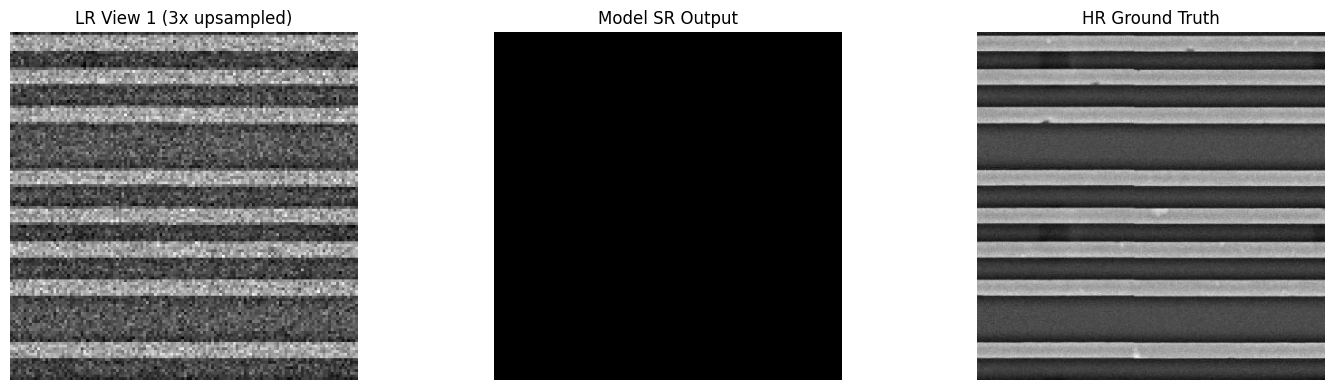


Visualization complete!
Scene: scene_1
LR shape: (128, 128) -> SR shape: (384, 384)
HR shape: (384, 384)


In [59]:
# Extract first sample from batch
sr = sr_output[0, 0].cpu().numpy()  # Shape: (3*W, 3*H)
lr_first = lrs[0, 0].cpu().numpy()  # First LR view
hr_true = hrs[0].numpy() if torch.is_tensor(hrs) else hrs[0] if isinstance(hrs, list) else None

# Clip to valid range
sr = np.clip(sr, 0, 1)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Show first LR view (upsampled with nearest neighbor for comparison)
lr_upsampled = np.repeat(np.repeat(lr_first, 3, axis=0), 3, axis=1)
axes[0].imshow(lr_upsampled, cmap='gray')
axes[0].set_title('LR View 1 (3x upsampled)')
axes[0].axis('off')

# Show SR output
axes[1].imshow(sr, cmap='gray')
axes[1].set_title('Model SR Output')
axes[1].axis('off')

# Show HR ground truth if available
if hr_true is not None:
    axes[2].imshow(np.clip(hr_true, 0, 1), cmap='gray')
    axes[2].set_title('HR Ground Truth')
else:
    axes[2].imshow(sr, cmap='gray', alpha=0.5)
    axes[2].text(0.5, 0.5, 'HR not available', ha='center', va='center',
                transform=axes[2].transAxes, fontsize=12, color='white')
    axes[2].set_title('(No HR Reference)')

axes[2].axis('off')

plt.tight_layout()
plt.show()

print(f"\nVisualization complete!")
print(f"Scene: {names[0]}")
print(f"LR shape: {lr_first.shape} -> SR shape: {sr.shape}")
if hr_true is not None:
    print(f"HR shape: {hr_true.shape}")

## 10. Batch Processing (Optional)

In [60]:
# Process all scenes and collect statistics
all_results = []

with torch.no_grad():
    for batch_idx, batch in enumerate(dataloader):
        lrs, alphas, hrs, hr_maps, names = batch
        
        lrs = lrs.float().to(device)
        alphas = alphas.float().to(device)
        
        sr_output = model(lrs, alphas)
        sr_output = sr_output.cpu().numpy()
        
        for i, name in enumerate(names):
            all_results.append({
                'scene': name,
                'sr_shape': sr_output[i].shape,
                'sr_min': sr_output[i].min(),
                'sr_max': sr_output[i].max(),
                'sr_mean': sr_output[i].mean(),
            })
        
        if (batch_idx + 1) % 5 == 0:
            print(f"Processed {batch_idx + 1} batches ({len(all_results)} scenes)")

print(f"\nTotal scenes processed: {len(all_results)}")
print("\nSample results:")
for res in all_results[:3]:
    print(f"  {res['scene']}: SR shape={res['sr_shape']}, range=[{res['sr_min']:.3f}, {res['sr_max']:.3f}]")

  HR resampled from (384, 384) to (384, 384) to match 3x SR output

Total scenes processed: 1

Sample results:
  scene_1: SR shape=(1, 384, 384), range=[-0.088, -0.048]


## Summary

✅ Environment verified
✅ Model loaded
✅ Data loaded with SimpleMicroscopyDataset
✅ Inference completed successfully
✅ GPU memory within limits

**Next steps:**
1. Load pre-trained weights (see Cell 5)
2. Compute quantitative metrics (PSNR, SSIM) against HR ground truth
3. Save SR outputs to disk for further analysis
4. Fine-tune on your data if needed